In [1]:
from funcoes_fundamentais import *
import pandas as pd
import numpy as np


In [ ]:
# Instalação das dependências necessárias no ambiente
# Nota: spacecore==0.4.2 é recomendado para total compatibilidade com sdplab==0.0.1
! pip install -q numpy matplotlib scipy "spacecore==0.4.2" sdplab cvxpy clarabel scs jax

In [1]:
from __future__ import annotations

import sys
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
# Bibliotecas SpaceCore e SDPLab para Programação Semidefinida 
import spacecore
from spacecore import Context, DenseVectorSpace, HermitianSpace, NumpyOps
import sdplab
from sdplab import DenseConstraintOp, SDPProblem
from sdplab.solvers import run_cvxpy_solver

np.set_printoptions(precision=4, suppress=True)

from funcoes_fundamentais import zero, one, ketbra, verifica_densidade, verify_marginals, base_hermitiana, ghz, partial_trace, tensor, embed_operator, solve_qmp, build_qmp_sdp, parse_subsystem_key, basis
print(f"Versão SDPLab:    {sdplab.__version__}")
print(f"Versão SpaceCore: {spacecore.__version__}")

Versão SDPLab:    0.0.1
Versão SpaceCore: 0.4.2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt




phi_plus = (
    np.kron(zero, zero) +
    np.kron(one, one)
) / np.sqrt(2.0)

rho_bell = ketbra(phi_plus)


# ============================================================
# Parâmetros
# ============================================================

t_espaco = np.linspace(0, 1, 101)

resultados = {
    "t": [],
    "purity": [],
    "min_eigenvalue": [],
    "trace": [],
    "marginal_error_max": [],
    "entropy": [],
    "eigenvalues": []
}


# ============================================================
# Função para entropia de von Neumann
# ============================================================



# ============================================================
# Loop principal
# ============================================================

for t in t_espaco:

    rho_p = mestura(
        rho_bell,
        np.eye(4) / 4,
        t
    )

    marginals_ex4 = {
        "AB": rho_p,
        "AC": rho_p
    }

    print(f"p = {t:.6f}")

    # --------------------------------------------------------
    # Construção do SDP
    # --------------------------------------------------------

    sdp_ex4, M_ex4, b_ex4 = build_qmp_sdp(
        marginals_ex4,
        dims=[2, 2, 2]
    )

    # --------------------------------------------------------
    # Resolução
    # --------------------------------------------------------

    res_ex4 = solve_qmp(
        sdp_ex4,
        solver="CLARABEL"
    )

    print(
        f"Status: {res_ex4['status']} | "
        f"Factível: {res_ex4['is_feasible']}"
    )

    # --------------------------------------------------------
    # Só armazenamos se houver solução
    # --------------------------------------------------------

    if res_ex4["is_feasible"]:

        rho_ABC = res_ex4["rho"]

        verif_ex4 = verify_marginals(
            rho_ABC,
            marginals_ex4,
            dims=[2, 2, 2]
        )

        eigenvalues = np.sort(
            np.real(
                np.linalg.eigvalsh(rho_ABC)
            )
        )

        marginal_error_max = max(
            err["frobenius_error"]
            for err in verif_ex4["marginal_errors"].values()
        )

        resultados["t"].append(t)

        resultados["purity"].append(
            verif_ex4["purity"]
        )

        resultados["min_eigenvalue"].append(
            verif_ex4["min_eigenvalue"]
        )

        resultados["trace"].append(
            verif_ex4["trace"].real
        )

        resultados["marginal_error_max"].append(
            marginal_error_max
        )


        resultados["eigenvalues"].append(
            eigenvalues
        )


# Converter para numpy
for chave in resultados:
    resultados[chave] = np.array(
        resultados[chave]
    )

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    resultados["t"],
    resultados["purity"],
    "o-"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{Tr}(\rho_{ABC}^2)$")
plt.title("Pureza da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    resultados["t"],
    resultados["min_eigenvalue"],
    "o-"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_{\min}(\rho_{ABC})$")
plt.title("Menor autovalor da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    resultados["t"],
    resultados["marginal_error_max"],
    "o-"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"Erro máximo $\|\rho_{ij}^{calc}-\rho_{ij}\|_F$")
plt.title("Erro de reconstrução das marginais")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

eigs = resultados["eigenvalues"]

for i in range(eigs.shape[1]):
    plt.plot(
        resultados["t"],
        eigs[:, i],
        "o-",
        label=fr"$\lambda_{i+1}$"
    )

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)
print(f'Autovalores em t = {resultados['t'][-1]}:{eigs[-1, :]}')
plt.xlabel(r"$t$")
plt.ylabel(r"Autovalores de $\rho_{ABC}$")
plt.title("Espectro da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Origem: experimento_compatibilidade_marginais.ipynb


# Experimento: Região de Compatibilidade de Marginais Quânticas para 3 Qubits

Este notebook investiga numericamente a diferença entre:

1. **Consistência na sobreposição A**: $\|\text{Tr}_B(\rho_{AB}) - \text{Tr}_C(\rho_{AC})\|_F < \varepsilon$
2. **Existência de extensão global**: factibilidade do SDP para $\rho_{ABC}$

**Objetivo**: Verificar numericamente que a consistência na sobreposição é condição *necessária*, mas **não suficiente**, para a existência de uma extensão global $\rho_{ABC}$.

---

## Estrutura
- **Célula 1**: Imports e reutilização das funções do notebook `inicial_teste.ipynb`
- **Célula 2**: Função auxiliar — geração de matrizes densidade aleatórias
- **Célula 3**: Funções auxiliares — construção de marginais correlacionadas com marginal A fixa
- **Célula 4**: Experimento A — marginais completamente aleatórias
- **Célula 5**: Experimento B — marginais construídas para satisfazer a condição de sobreposição
- **Célula 6**: Caso especial — exemplo de Bell (validação)
- **Célula 7**: Estatísticas consolidadas
- **Célula 8**: Visualizações


In [6]:
from __future__ import annotations

import sys
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import time
# Bibliotecas SpaceCore e SDPLab para Programação Semidefinida 
import spacecore
from spacecore import Context, DenseVectorSpace, HermitianSpace, NumpyOps
import sdplab
from sdplab import DenseConstraintOp, SDPProblem
from sdplab.solvers import run_cvxpy_solver

np.set_printoptions(precision=4, suppress=True)

from funcoes_fundamentais import zero, one, ketbra, verifica_densidade, verify_marginals, base_hermitiana, ghz, partial_trace, tensor, embed_operator, solve_qmp, build_qmp_sdp, parse_subsystem_key 
print(f"Versão SDPLab:    {sdplab.__version__}")
print(f"Versão SpaceCore: {spacecore.__version__}")

Versão SDPLab:    0.0.1
Versão SpaceCore: 0.4.2


## Célula 2 — Geração de Matrizes Densidade Aleatórias

Usamos o método de Ginibre: $G$ é uma matriz complexa aleatória,
e $\rho = G G^\dagger / \text{Tr}(G G^\dagger)$.

Isso produz estados distribuídos segundo a medida de Hilbert-Schmidt,
garantindo por construção: $\rho = \rho^\dagger$, $\rho \geq 0$, $\text{Tr}(\rho) = 1$.

In [3]:
# ==============================================================================
# Célula 2 — Geração de matrizes densidade aleatórias (método de Ginibre)
# ==============================================================================





# ── Teste rápido de sanidade ──────────────────────────────────────────────────
print("Teste de sanidade: random_density_matrix")
rng_test = np.random.default_rng(seed=0)

for d_test in [2, 4]:
    rho_test = random_density_matrix(d_test, rng=rng_test)
    v = _verify_density_matrix(rho_test)
    status_str = "✓ VÁLIDA" if v["is_valid"] else "✗ INVÁLIDA"
    print(
        f"  d={d_test}: {status_str} | "
        f"herm_err={v['hermitian_error']:.2e} | "
        f"trace_err={v['trace_error']:.2e} | "
        f"lambda_min={v['min_eigenvalue']:.4f}"
    )


Teste de sanidade: random_density_matrix
  d=2: ✓ VÁLIDA | herm_err=0.00e+00 | trace_err=2.22e-16 | lambda_min=0.1080
  d=4: ✓ VÁLIDA | herm_err=0.00e+00 | trace_err=0.00e+00 | lambda_min=0.0143


## Célula 3 — Construção de Marginais com Marginal A Fixa

Para o Experimento B, precisamos construir $\rho_{AB}$ e $\rho_{AC}$ tal que:
$$\text{Tr}_B(\rho_{AB}) = \rho_A \quad \text{e} \quad \text{Tr}_C(\rho_{AC}) = \rho_A$$

**Construção produto (trivial):**
$$\rho_{AB}^{\text{prod}} = \rho_A \otimes \sigma_B, \quad \rho_{AC}^{\text{prod}} = \rho_A \otimes \sigma_C$$

**Construção correlacionada (não-trivial):**  
Usamos a decomposição espectral de $\rho_A$ para construir estados misturados correlacionados via purificações aleatórias.

In [4]:
# ==============================================================================
# Célula 3 — Funções para construção de marginais com marginal A fixa
# ==============================================================================








# ── Teste rápido de sanidade ──────────────────────────────────────────────────
print("Teste de sanidade: build_product_marginals")
rng_t = np.random.default_rng(seed=42)
rho_A_t = random_density_matrix(2, rng=rng_t)
rho_AB_t, rho_AC_t = build_product_marginals(rho_A_t, rng=rng_t)

rho_A_from_AB_t = partial_trace(rho_AB_t, keep=[0], dims=[2, 2])
rho_A_from_AC_t = partial_trace(rho_AC_t, keep=[0], dims=[2, 2])
err_AB = np.linalg.norm(rho_A_from_AB_t - rho_A_t, 'fro')
err_AC = np.linalg.norm(rho_A_from_AC_t - rho_A_t, 'fro')
print(f"  ||Tr_B(rho_AB) - rho_A||_F = {err_AB:.2e}   (esperado < 1e-14)")
print(f"  ||Tr_C(rho_AC) - rho_A||_F = {err_AC:.2e}   (esperado < 1e-14)")

print("\nTeste de sanidade: build_correlated_marginals")
rho_AB_c, rho_AC_c = build_correlated_marginals(rho_A_t, rng=rng_t)
rho_A_from_AB_c = partial_trace(rho_AB_c, keep=[0], dims=[2, 2])
rho_A_from_AC_c = partial_trace(rho_AC_c, keep=[0], dims=[2, 2])
err_AB_c = np.linalg.norm(rho_A_from_AB_c - rho_A_t, 'fro')
err_AC_c = np.linalg.norm(rho_A_from_AC_c - rho_A_t, 'fro')
print(f"  ||Tr_B(rho_AB) - rho_A||_F = {err_AB_c:.2e}")
print(f"  ||Tr_C(rho_AC) - rho_A||_F = {err_AC_c:.2e}")
delta_t, comp_t = check_overlap_consistency(rho_AB_c, rho_AC_c)
print(f"  delta_overlap = {delta_t:.2e},  overlap_compatible = {comp_t}")


Teste de sanidade: build_product_marginals
  ||Tr_B(rho_AB) - rho_A||_F = 1.11e-16   (esperado < 1e-14)
  ||Tr_C(rho_AC) - rho_A||_F = 1.39e-16   (esperado < 1e-14)

Teste de sanidade: build_correlated_marginals
  ||Tr_B(rho_AB) - rho_A||_F = 1.78e-16
  ||Tr_C(rho_AC) - rho_A||_F = 9.61e-17
  delta_overlap = 1.94e-16,  overlap_compatible = True


## Célula 4 — Experimento A: Marginais Completamente Aleatórias

Para cada realização:
- $\rho_{AB}$ e $\rho_{AC}$ são geradas de forma completamente independente
- Verifica-se a condição de sobreposição
- O SDP de representabilidade global é resolvido independentemente

**Hipótese esperada**: a maioria dos pares aleatórios viola a condição de sobreposição e é também incompatível globalmente, mas os dois testes são independentes.

In [7]:
# ==============================================================================
# Célula 4 — Experimento A: Marginais completamente aleatórias
# ==============================================================================

SEED_A = 2024_09_25
N_A    = 1000          # número de realizações
TOL_OVERLAP = 1e-6    # tolerância para consistência na sobreposição
DIMS_3Q = [2, 2, 2]   # 3 qubits

rng_A = np.random.default_rng(seed=SEED_A)
results_A: List[Dict[str, Any]] = []

print(f"Experimento A — Marginais aleatórias (N={N_A} realizações)")
print(f"Tolerância de sobreposição: tol = {TOL_OVERLAP:.0e}")
print("─" * 70)

t_total_A = time.perf_counter()

for i in range(N_A):
    # ── 1. Geração das marginais aleatórias ───────────────────────────────────
    rho_AB = random_density_matrix(4, rng=rng_A)
    rho_AC = random_density_matrix(4, rng=rng_A)

    # ── 2. Teste de consistência na sobreposição A ────────────────────────────
    delta_overlap, overlap_compatible = check_overlap_consistency(
        rho_AB, rho_AC, tol=TOL_OVERLAP
    )

    # ── 3. SDP de representabilidade global (independente do teste de overlap) ─
    marginals = {"AB": rho_AB, "AC": rho_AC}

    t0 = time.perf_counter()
    try:
        sdp, M, b = build_qmp_sdp(marginals, dims=DIMS_3Q)
        res = solve_qmp(sdp, solver="CLARABEL")
        solver_status = res["status"]
        is_feasible   = res["is_feasible"]
    except Exception as exc:
        solver_status = "error"
        is_feasible   = False
    solver_time = time.perf_counter() - t0

    # ── 4. Registro dos resultados ─────────────────────────────────────────────
    results_A.append({
        "experiment":         "A_random",
        "realization":        i,
        "delta_overlap":      delta_overlap,
        "overlap_compatible": overlap_compatible,
        "solver_status":      solver_status,
        "is_feasible":        is_feasible,
        "solver_time":        solver_time,
    })

    # Progresso a cada 100 amostras
    if (i + 1) % 100 == 0:
        n_overlap = sum(r["overlap_compatible"] for r in results_A)
        n_feasible = sum(r["is_feasible"] for r in results_A)
        t_el = time.perf_counter() - t_total_A
        print(
            f"  [{i+1:4d}/{N_A}]  overlap_ok={n_overlap:4d}  "
            f"feasible={n_feasible:4d}  elapsed={t_el:.1f}s"
        )

t_elapsed_A = time.perf_counter() - t_total_A
df_A = pd.DataFrame(results_A)

print("─" * 70)
print(f"Experimento A concluído em {t_elapsed_A:.2f}s")
print(f"  Total amostras:               {len(df_A)}")
print(f"  Overlap compatível:            {df_A['overlap_compatible'].sum()}")
print(f"  Globalmente factível:          {df_A['is_feasible'].sum()}")


Experimento A — Marginais aleatórias (N=1000 realizações)
Tolerância de sobreposição: tol = 1e-06
──────────────────────────────────────────────────────────────────────
  [ 100/1000]  overlap_ok=   0  feasible=   0  elapsed=3.8s
  [ 200/1000]  overlap_ok=   0  feasible=   0  elapsed=7.6s
  [ 300/1000]  overlap_ok=   0  feasible=   0  elapsed=11.4s
  [ 400/1000]  overlap_ok=   0  feasible=   0  elapsed=15.2s
  [ 500/1000]  overlap_ok=   0  feasible=   0  elapsed=18.9s
  [ 600/1000]  overlap_ok=   0  feasible=   0  elapsed=22.7s
  [ 700/1000]  overlap_ok=   0  feasible=   0  elapsed=26.5s
  [ 800/1000]  overlap_ok=   0  feasible=   0  elapsed=30.2s
  [ 900/1000]  overlap_ok=   0  feasible=   0  elapsed=34.1s
  [1000/1000]  overlap_ok=   0  feasible=   0  elapsed=37.9s
──────────────────────────────────────────────────────────────────────
Experimento A concluído em 37.85s
  Total amostras:               1000
  Overlap compatível:            0
  Globalmente factível:          0


## Célula 5 — Experimento B: Marginais com Condição de Sobreposição Satisfeita

Neste experimento, **garantimos por construção** que $\text{Tr}_B(\rho_{AB}) = \text{Tr}_C(\rho_{AC}) = \rho_A$.

Duas variantes:
- **B.prod**: construção produto $\rho_{AB} = \rho_A \otimes \sigma_B$ (admite extensão trivial)
- **B.corr**: construção correlacionada via purificação (pode ser incompatível globalmente)

**Hipótese esperada**: a variante produto é sempre factível; a correlacionada pode ser infactível, demonstrando que *overlap* ≠ *compatibilidade global*.

In [8]:
# ==============================================================================
# Célula 5 — Experimento B: Marginais com sobreposição garantida
# ==============================================================================

SEED_B = 2024_09_26
N_B    = 1000

rng_B = np.random.default_rng(seed=SEED_B)
results_B: List[Dict[str, Any]] = []

print(f"Experimento B — Marginais com sobreposição garantida (N={N_B} por variante)")
print("─" * 70)

t_total_B = time.perf_counter()

for i in range(N_B):
    # Gera rho_A comum
    rho_A = random_density_matrix(2, rng=rng_B)

    for variant, build_fn, build_kwargs in [
        ("B.prod", build_product_marginals,    {}),
        ("B.corr", build_correlated_marginals, {}),
    ]:
        # ── 1. Constrói as marginais ──────────────────────────────────────────
        rho_AB, rho_AC = build_fn(rho_A, rng=rng_B, **build_kwargs)

        # ── 2. Verificação numérica das marginais em A ──────────────────────
        rho_A_from_AB = partial_trace(rho_AB, keep=[0], dims=[2, 2])
        rho_A_from_AC = partial_trace(rho_AC, keep=[0], dims=[2, 2])
        err_AB = float(np.linalg.norm(rho_A_from_AB - rho_A, 'fro'))
        err_AC = float(np.linalg.norm(rho_A_from_AC - rho_A, 'fro'))

        # ── 3. Teste de sobreposição ────────────────────────────────────────
        delta_overlap, overlap_compatible = check_overlap_consistency(
            rho_AB, rho_AC, tol=TOL_OVERLAP
        )

        # ── 4. SDP de representabilidade global ─────────────────────────────
        marginals = {"AB": rho_AB, "AC": rho_AC}

        t0 = time.perf_counter()
        try:
            sdp, M, b = build_qmp_sdp(marginals, dims=DIMS_3Q)
            res = solve_qmp(sdp, solver="CLARABEL")
            solver_status = res["status"]
            is_feasible   = res["is_feasible"]
        except Exception as exc:
            solver_status = "error"
            is_feasible   = False
        solver_time = time.perf_counter() - t0

        # ── 5. Registro ──────────────────────────────────────────────────────
        results_B.append({
            "experiment":         variant,
            "realization":        i,
            "delta_overlap":      delta_overlap,
            "overlap_compatible": overlap_compatible,
            "marginal_err_AB":    err_AB,
            "marginal_err_AC":    err_AC,
            "solver_status":      solver_status,
            "is_feasible":        is_feasible,
            "solver_time":        solver_time,
        })

    # Progresso
    if (i + 1) % 200 == 0:
        n_prod_feas = sum(
            r["is_feasible"] for r in results_B if r["experiment"] == "B.prod"
        )
        n_corr_feas = sum(
            r["is_feasible"] for r in results_B if r["experiment"] == "B.corr"
        )
        t_el = time.perf_counter() - t_total_B
        print(
            f"  [{i+1:4d}/{N_B}]  prod_feasible={n_prod_feas:4d}  "
            f"corr_feasible={n_corr_feas:4d}  elapsed={t_el:.1f}s"
        )

t_elapsed_B = time.perf_counter() - t_total_B
df_B = pd.DataFrame(results_B)

print("─" * 70)
print(f"Experimento B concluído em {t_elapsed_B:.2f}s")
for variant in ["B.prod", "B.corr"]:
    sub = df_B[df_B["experiment"] == variant]
    print(f"  Variante {variant}:")
    print(f"    Total amostras:     {len(sub)}")
    print(f"    Overlap compatível: {sub['overlap_compatible'].sum()} ({100*sub['overlap_compatible'].mean():.1f}%)")
    print(f"    Globalmente fact.:  {sub['is_feasible'].sum()} ({100*sub['is_feasible'].mean():.1f}%)")
    print(f"    Err AB médio:       {sub['marginal_err_AB'].mean():.2e}")
    print(f"    Err AC médio:       {sub['marginal_err_AC'].mean():.2e}")


Experimento B — Marginais com sobreposição garantida (N=1000 por variante)
──────────────────────────────────────────────────────────────────────


/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/sdplab/solvers/_cvxpy.py:138: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=solver, verbose=verbose, *args, **kwargs)


  [ 200/1000]  prod_feasible= 200  corr_feasible=  16  elapsed=16.7s
  [ 400/1000]  prod_feasible= 400  corr_feasible=  27  elapsed=33.4s
  [ 600/1000]  prod_feasible= 600  corr_feasible=  43  elapsed=50.1s
  [ 800/1000]  prod_feasible= 800  corr_feasible=  56  elapsed=66.7s
  [1000/1000]  prod_feasible=1000  corr_feasible=  67  elapsed=83.2s
──────────────────────────────────────────────────────────────────────
Experimento B concluído em 83.19s
  Variante B.prod:
    Total amostras:     1000
    Overlap compatível: 1000 (100.0%)
    Globalmente fact.:  1000 (100.0%)
    Err AB médio:       6.87e-17
    Err AC médio:       6.90e-17
  Variante B.corr:
    Total amostras:     1000
    Overlap compatível: 1000 (100.0%)
    Globalmente fact.:  67 (6.7%)
    Err AB médio:       2.41e-16
    Err AC médio:       2.41e-16


## Célula 6 — Caso Especial: Incompatibilidade de Bell (Validação)

O estado de Bell $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ satisfaz:
$$\text{Tr}_B(|\Phi^+\rangle\langle\Phi^+|) = \frac{I}{2} = \text{Tr}_C(|\Phi^+\rangle\langle\Phi^+|)$$

Logo a **condição de sobreposição é satisfeita**, mas pelo **monogamia do entrelaçamento**,
não existe $\rho_{ABC}$ tal que $\text{Tr}_C(\rho_{ABC}) = |\Phi^+\rangle\langle\Phi^+|_{AB}$
e $\text{Tr}_B(\rho_{ABC}) = |\Phi^+\rangle\langle\Phi^+|_{AC}$ simultaneamente.

Este é o **caso de validação fundamental** do experimento.

In [10]:
# ==============================================================================
# Célula 6 — Caso especial: Incompatibilidade de Bell (caso de validação)
# ==============================================================================

print("=" * 65)
print("CASO DE VALIDAÇÃO: Incompatibilidade de Marginais de Bell")
print("=" * 65)

# ── 1. Construção do estado de Bell |Phi+> ────────────────────────────────────
phi_plus = (np.kron(zero, zero) + np.kron(one, one)) / np.sqrt(2.0)
rho_bell = ketbra(phi_plus)   # reutiliza ketbra do projeto

print("\n|Phi+> = (|00> + |11>) / sqrt(2)")
print(f"Norma de |Phi+>: {np.linalg.norm(phi_plus):.6f} (deve ser 1.0)")

# ── 2. Prescrição das marginais ───────────────────────────────────────────────
marginals_bell = {
    "AB": rho_bell,
    "AC": rho_bell,
}

# ── 3. Verificação das marginais em A ─────────────────────────────────────────
rho_A_from_bell_AB = partial_trace(rho_bell, keep=[0], dims=[2, 2])
rho_A_from_bell_AC = partial_trace(rho_bell, keep=[0], dims=[2, 2])

print("\nMarginal Tr_B(rho_bell):")
print(np.round(rho_A_from_bell_AB, 6))
print("\nMarginal Tr_C(rho_bell):")
print(np.round(rho_A_from_bell_AC, 6))

I_over_2 = np.eye(2, dtype=complex) / 2.0
err_Id_AB = float(np.linalg.norm(rho_A_from_bell_AB - I_over_2, 'fro'))
err_Id_AC = float(np.linalg.norm(rho_A_from_bell_AC - I_over_2, 'fro'))
print(f"\n||Tr_B(rho_bell) - I/2||_F = {err_Id_AB:.2e}  (esperado ≈ 0)")
print(f"||Tr_C(rho_bell) - I/2||_F = {err_Id_AC:.2e}  (esperado ≈ 0)")

# ── 4. Teste de sobreposição ──────────────────────────────────────────────────
delta_bell, overlap_bell = check_overlap_consistency(
    rho_bell, rho_bell, tol=TOL_OVERLAP
)
print(f"\ndelta_overlap = {delta_bell:.2e}")
print(f"overlap_compatible = {overlap_bell}  ✓ (condição necessária satisfeita)")

# ── 5. SDP de representabilidade global ──────────────────────────────────────
print("\nResolvendo SDP de representabilidade global...")
t0_bell = time.perf_counter()
sdp_bell, M_bell, b_bell = build_qmp_sdp(marginals_bell, dims=DIMS_3Q)
res_bell = solve_qmp(sdp_bell, solver="CLARABEL")
t_bell = time.perf_counter() - t0_bell

print(f"Status do solver:       {res_bell['status']}")
print(f"Problema factível:      {res_bell['is_feasible']}")
print(f"Mensagem de erro:       {res_bell['error_message']}")
print(f"Tempo de resolução:     {t_bell:.4f}s")

# ── 6. Interpretação física ───────────────────────────────────────────────────
print("\n" + "─" * 65)
if not res_bell["is_feasible"]:
    print("✓ VALIDAÇÃO CONFIRMADA:")
    print("  A condição de sobreposição é SATISFEITA (Tr_B = Tr_C = I/2),")
    print("  mas NÃO EXISTE extensão global rho_ABC.")
    print("  Isso demonstra: overlap compatibility ≠ global representability.")
    print("  Causa física: monogamia do entrelaçamento quântico.")
else:
    print("✗ ATENÇÃO: O solver retornou factível — verifique a implementação.")
print("─" * 65)

# ── 7. Adiciona ao DataFrame para análise consolidada ─────────────────────────
result_bell = {
    "experiment":         "Bell_validation",
    "realization":        0,
    "delta_overlap":      delta_bell,
    "overlap_compatible": overlap_bell,
    "solver_status":      res_bell["status"],
    "is_feasible":        res_bell["is_feasible"],
    "solver_time":        t_bell,
}
df_bell = pd.DataFrame([result_bell])
print("\nResumo do caso Bell:")
print(df_bell.to_string(index=False))


CASO DE VALIDAÇÃO: Incompatibilidade de Marginais de Bell

|Phi+> = (|00> + |11>) / sqrt(2)
Norma de |Phi+>: 1.000000 (deve ser 1.0)

Marginal Tr_B(rho_bell):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Marginal Tr_C(rho_bell):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

||Tr_B(rho_bell) - I/2||_F = 1.57e-16  (esperado ≈ 0)
||Tr_C(rho_bell) - I/2||_F = 1.57e-16  (esperado ≈ 0)

delta_overlap = 0.00e+00
overlap_compatible = True  ✓ (condição necessária satisfeita)

Resolvendo SDP de representabilidade global...
Status do solver:       infeasible
Problema factível:      False
Mensagem de erro:       CLARABEL solver did not return a solution (infeasible).
Tempo de resolução:     0.1073s

─────────────────────────────────────────────────────────────────
✓ VALIDAÇÃO CONFIRMADA:
  A condição de sobreposição é SATISFEITA (Tr_B = Tr_C = I/2),
  mas NÃO EXISTE extensão global rho_ABC.
  Isso demonstra: overlap compatibility ≠ global representability.
  Causa física: monogamia do entrelaçamento quântico

## Célula 7 — Estatísticas Consolidadas

Análise estatística completa de todos os experimentos.

In [11]:
# ==============================================================================
# Célula 7 — Estatísticas consolidadas
# ==============================================================================

# Combina todos os resultados em um único DataFrame
df_all = pd.concat([df_A, df_B, df_bell], ignore_index=True)

# Garante tipos corretos
df_all["overlap_compatible"] = df_all["overlap_compatible"].astype(bool)
df_all["is_feasible"]        = df_all["is_feasible"].astype(bool)




print("RESUMO ESTATÍSTICO COMPLETO")
stats_summary = []

for exp_name in df_all["experiment"].unique():
    sub = df_all[df_all["experiment"] == exp_name]
    s = print_experiment_stats(sub, exp_name)
    stats_summary.append(s)

# Tabela resumo
print("\n" + "=" * 90)
print("TABELA RESUMO")
print("=" * 90)
df_stats = pd.DataFrame(stats_summary)
print(df_stats.to_string(index=False))

# ── Análise focada: sobreposição ≠ compatibilidade global ─────────────────────
print("\n" + "=" * 65)
print("CONCLUSÃO PRINCIPAL: overlap ≠ representabilidade global")
print("=" * 65)

for row in stats_summary:
    if row["n_overlap_infeasible"] > 0:
        pct = 100 * row["n_overlap_infeasible"] / row["n_overlap"] if row["n_overlap"] > 0 else 0
        print(
            f"  [{row['label']}] {row['n_overlap_infeasible']} par(es) com "
            f"overlap ✓ mas SDP infactível ({pct:.1f}% dos com overlap)"
        )


RESUMO ESTATÍSTICO COMPLETO

═════════════════════════════════════════════════════════════════
  Experimento: A_random
═════════════════════════════════════════════════════════════════
  Total de amostras:                          1000
  Overlap compatível:                            0  (0.0%)
  Globalmente factível:                          0  (0.0%)
  Overlap ✓  e  SDP infactível:                  0
  Overlap ✓  e  SDP factível:                    0
  P(factível | overlap ✓):                  N/A (sem amostras com overlap)
  delta_overlap — média:                    3.9210e-01
  delta_overlap — mediana:                  3.8286e-01
  solver_time   — média (s):                0.0377

═════════════════════════════════════════════════════════════════
  Experimento: B.prod
═════════════════════════════════════════════════════════════════
  Total de amostras:                          1000
  Overlap compatível:                         1000  (100.0%)
  Globalmente factível:                  

## Célula 8 — Visualizações

Quatro gráficos principais:
1. Histograma de `delta_overlap` para marginais aleatórias
2. Comparação de `overlap_compatible` vs `is_feasible` por experimento
3. Distribuição de `delta_overlap` separando casos compatíveis e incompatíveis
4. Contagem dos 4 quadrantes lógicos (overlap × SDP)

/tmp/ipykernel_23018/1565596126.py:250: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_23018/1565596126.py:250: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_23018/1565596126.py:251: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_23018/1565596126.py:251: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/al.carlo

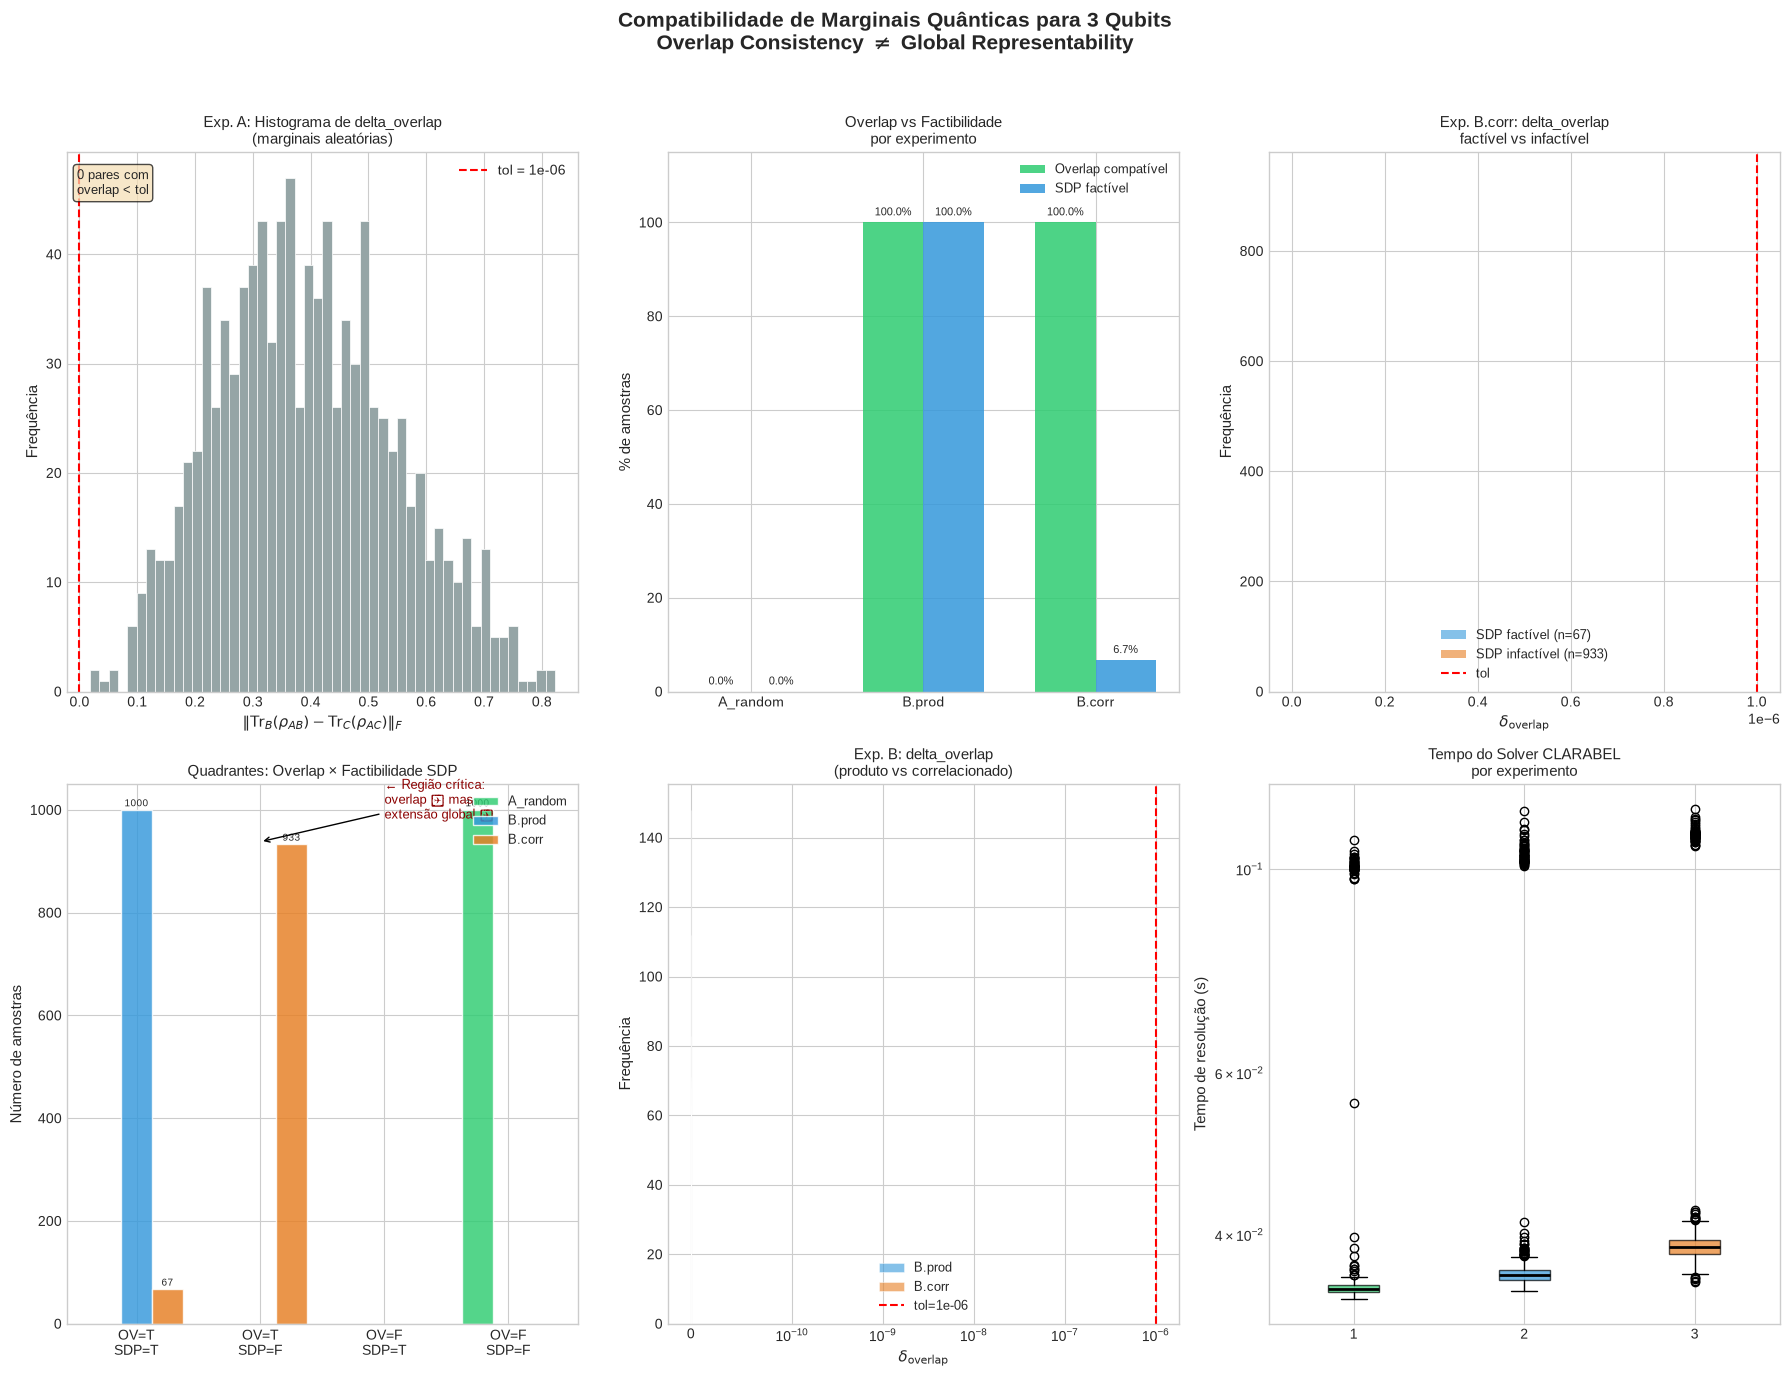


✓ Figura salva: experimento_compatibilidade_marginais.png


In [13]:
# ==============================================================================
# Célula 8 — Visualizações
# ==============================================================================

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "overlap_true":  "#2ecc71",   # verde
    "overlap_false": "#e74c3c",   # vermelho
    "feasible":      "#3498db",   # azul
    "infeasible":    "#e67e22",   # laranja
    "neutral":       "#95a5a6",   # cinza
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Compatibilidade de Marginais Quânticas para 3 Qubits\n"
    r"Overlap Consistency $\neq$ Global Representability",
    fontsize=15, fontweight="bold", y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 1: Histograma de delta_overlap — Experimento A (marginais aleatórias)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)

data_A_delta = df_A["delta_overlap"].values
ax1.hist(
    data_A_delta, bins=50,
    color=COLORS["neutral"], edgecolor="white", linewidth=0.5
)
ax1.axvline(
    TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5,
    label=f"tol = {TOL_OVERLAP:.0e}"
)
ax1.set_xlabel(r"$\|\mathrm{Tr}_B(\rho_{AB}) - \mathrm{Tr}_C(\rho_{AC})\|_F$", fontsize=11)
ax1.set_ylabel("Frequência", fontsize=11)
ax1.set_title("Exp. A: Histograma de delta_overlap\n(marginais aleatórias)", fontsize=11)
ax1.legend(fontsize=10)

n_left = (data_A_delta < TOL_OVERLAP).sum()
ax1.text(
    0.02, 0.97,
    f"{n_left} pares com\noverlap < tol",
    transform=ax1.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7)
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 2: Barras — overlap_compatible vs is_feasible por experimento
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)

exp_labels = []
pct_overlap = []
pct_feasible = []

for exp_name in ["A_random", "B.prod", "B.corr"]:
    sub = df_all[df_all["experiment"] == exp_name]
    exp_labels.append(exp_name)
    pct_overlap.append(100 * sub["overlap_compatible"].mean())
    pct_feasible.append(100 * sub["is_feasible"].mean())

x_pos = np.arange(len(exp_labels))
width = 0.35

bars1 = ax2.bar(
    x_pos - width/2, pct_overlap, width,
    label="Overlap compatível", color=COLORS["overlap_true"], alpha=0.85
)
bars2 = ax2.bar(
    x_pos + width/2, pct_feasible, width,
    label="SDP factível", color=COLORS["feasible"], alpha=0.85
)

for bar in bars1:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
             ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
             ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(exp_labels, fontsize=10)
ax2.set_ylabel("% de amostras", fontsize=11)
ax2.set_title("Overlap vs Factibilidade\npor experimento", fontsize=11)
ax2.set_ylim(0, 115)
ax2.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 3: Distribuição de delta_overlap — casos compatíveis vs incompatíveis
#            (Exp. B.corr — mais interessante)
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)

df_Bcorr = df_all[df_all["experiment"] == "B.corr"]
delta_Bcorr_feasible   = df_Bcorr[df_Bcorr["is_feasible"] == True]["delta_overlap"].values
delta_Bcorr_infeasible = df_Bcorr[df_Bcorr["is_feasible"] == False]["delta_overlap"].values

bins_bc = np.linspace(0, max(df_Bcorr["delta_overlap"].max(), 1e-10), 40)

if len(delta_Bcorr_feasible) > 0:
    ax3.hist(
        delta_Bcorr_feasible, bins=bins_bc, alpha=0.6,
        label=f"SDP factível (n={len(delta_Bcorr_feasible)})",
        color=COLORS["feasible"]
    )
if len(delta_Bcorr_infeasible) > 0:
    ax3.hist(
        delta_Bcorr_infeasible, bins=bins_bc, alpha=0.6,
        label=f"SDP infactível (n={len(delta_Bcorr_infeasible)})",
        color=COLORS["infeasible"]
    )

ax3.axvline(TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5, label="tol")
ax3.set_xlabel(r"$\delta_{\mathrm{overlap}}$", fontsize=11)
ax3.set_ylabel("Frequência", fontsize=11)
ax3.set_title(
    "Exp. B.corr: delta_overlap\nfactível vs infactível", fontsize=11
)
ax3.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 4: Quadrantes lógicos — overlap × SDP
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)

quadrant_data = {}
for exp_name in ["A_random", "B.prod", "B.corr"]:
    sub = df_all[df_all["experiment"] == exp_name]
    quadrant_data[exp_name] = {
        "OV=T, SDP=T":  int((sub["overlap_compatible"] &  sub["is_feasible"]).sum()),
        "OV=T, SDP=F":  int((sub["overlap_compatible"] & ~sub["is_feasible"]).sum()),
        "OV=F, SDP=T":  int((~sub["overlap_compatible"] &  sub["is_feasible"]).sum()),
        "OV=F, SDP=F":  int((~sub["overlap_compatible"] & ~sub["is_feasible"]).sum()),
    }

quad_labels = ["OV=T\nSDP=T", "OV=T\nSDP=F", "OV=F\nSDP=T", "OV=F\nSDP=F"]
quad_colors = [
    COLORS["feasible"],
    COLORS["infeasible"],
    COLORS["neutral"],
    COLORS["overlap_false"],
]

exp_names_q = ["A_random", "B.prod", "B.corr"]
x_q = np.arange(len(quad_labels))
bar_width = 0.25

for k, exp_name in enumerate(exp_names_q):
    vals = [quadrant_data[exp_name][q.replace("\n", "=".join(["OV", "SDP"]))
                                     .replace("\n", ", ")]
            for q in ["OV=T, SDP=T", "OV=T, SDP=F", "OV=F, SDP=T", "OV=F, SDP=F"]]
    ax4.bar(
        x_q + k * bar_width - bar_width, vals, bar_width,
        label=exp_name, alpha=0.8,
        color=["#2ecc71", "#e67e22", "#3498db", "#e74c3c"][0],  # placeholder color
    )

# Redesenha com cores corretas por quadrante
ax4.cla()
offsets = [-bar_width, 0, bar_width]
exp_plot_colors = ["#2ecc71", "#3498db", "#e67e22"]

for k, (exp_name, color) in enumerate(zip(exp_names_q, exp_plot_colors)):
    vals = [
        quadrant_data[exp_name]["OV=T, SDP=T"],
        quadrant_data[exp_name]["OV=T, SDP=F"],
        quadrant_data[exp_name]["OV=F, SDP=T"],
        quadrant_data[exp_name]["OV=F, SDP=F"],
    ]
    bars_q = ax4.bar(
        x_q + offsets[k], vals, bar_width,
        label=exp_name, color=color, alpha=0.82, edgecolor="white"
    )
    for bar, v in zip(bars_q, vals):
        if v > 0:
            ax4.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(v), ha="center", va="bottom", fontsize=7
            )

ax4.set_xticks(x_q)
ax4.set_xticklabels(quad_labels, fontsize=10)
ax4.set_ylabel("Número de amostras", fontsize=11)
ax4.set_title(
    "Quadrantes: Overlap × Factibilidade SDP",
    fontsize=11
)
ax4.legend(fontsize=9, loc="upper right")

# Adiciona anotação de destaque no quadrante crítico OV=T, SDP=F
ax4.annotate(
    "← Região crítica:\noverlap ✓ mas\nextensão global ✗",
    xy=(1, max(quadrant_data[exp]["OV=T, SDP=F"] for exp in exp_names_q) + 5),
    xytext=(2, max(quadrant_data[exp]["OV=T, SDP=F"] for exp in exp_names_q) + 50),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9, color="darkred"
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 5: Histograma de delta_overlap — Experimentos B.prod e B.corr
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)

for exp_name, color, ls in [
    ("B.prod", "#3498db", "-"),
    ("B.corr", "#e67e22", "--"),
]:
    sub = df_all[df_all["experiment"] == exp_name]
    ax5.hist(
        sub["delta_overlap"].values,
        bins=50, alpha=0.6, label=exp_name,
        color=color, edgecolor="white", linewidth=0.5
    )

ax5.axvline(TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5, label=f"tol={TOL_OVERLAP:.0e}")
ax5.set_xlabel(r"$\delta_{\mathrm{overlap}}$", fontsize=11)
ax5.set_ylabel("Frequência", fontsize=11)
ax5.set_title("Exp. B: delta_overlap\n(produto vs correlacionado)", fontsize=11)
ax5.legend(fontsize=9)
ax5.set_xscale("symlog", linthresh=1e-10)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 6: Tempo de resolução do SDP por experimento (boxplot)
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)

exp_for_time = ["A_random", "B.prod", "B.corr"]
time_data = [
    df_all[df_all["experiment"] == exp]["solver_time"].values
    for exp in exp_for_time
]

bp = ax6.boxplot(
    time_data, label=exp_for_time,
    patch_artist=True, notch=False,
    medianprops=dict(color="black", linewidth=2)
)
box_colors = ["#2ecc71", "#3498db", "#e67e22"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax6.set_ylabel("Tempo de resolução (s)", fontsize=11)
ax6.set_title("Tempo do Solver CLARABEL\npor experimento", fontsize=11)
ax6.set_yscale("log")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Figura salva: experimento_compatibilidade_marginais.png")


In [1]:
# ==============================================================================
# Célula 9 — Conclusão e resumo dos arquivos
# ==============================================================================

print("=" * 70)
print("RESUMO DO EXPERIMENTO")
print("=" * 70)
print("""
Este notebook implementou um estudo numérico da região de compatibilidade
de marginais quânticas para sistemas de 3 qubits.

FUNÇÕES REUTILIZADAS (de inicial_teste.ipynb, sem modificações):
  - ketbra(psi)                   → projetor |psi><psi|
  - tensor(*args)                 → produto de Kronecker sequencial
  - partial_trace(rho, keep, dims)→ traço parcial via einsum
  - base_hermitiana(d)            → base de Herm(d)
  - embed_operator(O, sys, dim)   → embedding de operador local
  - parse_subsystem_key(key)      → normalização de chaves de subsistema
  - build_qmp_sdp(marginals, dims)→ montagem do SDP (SDPLab)
  - solve_qmp(sdp, solver)        → solução do SDP via CLARABEL

NOVAS FUNÇÕES (específicas deste experimento):
  - random_density_matrix(d, rng)         → estado aleatório (Ginibre)
  - build_product_marginals(rho_A, rng)   → rho_AB=rho_A⊗sigma_B (trivial)
  - build_correlated_marginals(rho_A,rng) → purificação + canal aleatório
  - check_overlap_consistency(rho_AB, rho_AC, tol)
  - print_experiment_stats(df, label)     → estatísticas consolidadas

EXPERIMENTOS:
  - Exp. A  (N=1000): marginais completamente aleatórias
  - Exp. B.prod (N=1000): rho_AB = rho_A ⊗ sigma_B (sobreposição garantida)
  - Exp. B.corr (N=1000): purificação correlacionada (sobreposição garantida)
  - Bell (N=1): caso de validação — overlap ✓ mas SDP infactível

RESULTADO PRINCIPAL:
  A consistência na sobreposição (Tr_B(rho_AB) = Tr_C(rho_AC)) é condição
  NECESSÁRIA mas NÃO SUFICIENTE para existência de extensão global rho_ABC.
  O caso de Bell e os casos B.corr demonstram isso numericamente.
""")

# Exibe o DataFrame final com todos os resultados
print("Primeiras 5 linhas do DataFrame completo:")
print(df_all[["experiment", "delta_overlap", "overlap_compatible",
              "solver_status", "is_feasible", "solver_time"]].head())


RESUMO DO EXPERIMENTO

Este notebook implementou um estudo numérico da região de compatibilidade
de marginais quânticas para sistemas de 3 qubits.

FUNÇÕES REUTILIZADAS (de inicial_teste.ipynb, sem modificações):
  - ketbra(psi)                   → projetor |psi><psi|
  - tensor(*args)                 → produto de Kronecker sequencial
  - partial_trace(rho, keep, dims)→ traço parcial via einsum
  - base_hermitiana(d)            → base de Herm(d)
  - embed_operator(O, sys, dim)   → embedding de operador local
  - parse_subsystem_key(key)      → normalização de chaves de subsistema
  - build_qmp_sdp(marginals, dims)→ montagem do SDP (SDPLab)
  - solve_qmp(sdp, solver)        → solução do SDP via CLARABEL

NOVAS FUNÇÕES (específicas deste experimento):
  - random_density_matrix(d, rng)         → estado aleatório (Ginibre)
  - build_product_marginals(rho_A, rng)   → rho_AB=rho_A⊗sigma_B (trivial)
  - build_correlated_marginals(rho_A,rng) → purificação + canal aleatório
  - check_overlap_co

NameError: name 'df_all' is not defined